# House Price Prediction with Neural Network
Using PyTorch to build a Multi-Layer Perceptron (MLP) for regression on the Housing dataset.

In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

torch.manual_seed(42)
np.random.seed(42)

## 1. Load & Explore Data

In [2]:
df = pd.read_csv('Housing.csv')
print('Shape:', df.shape)
print('\nData types:')
print(df.dtypes)
df.head()

Shape: (545, 13)

Data types:
price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


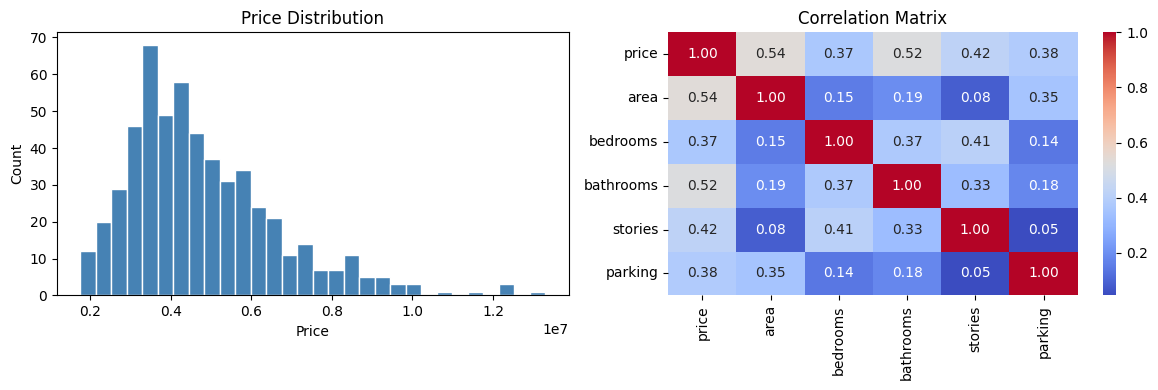

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['price'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Count')

sns.heatmap(df.select_dtypes(include='number').corr(), ax=axes[1], annot=True, fmt='.2f', cmap='coolwarm')
axes[1].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

## 2. Preprocessing

In [5]:
# Remove outliers (1st-99th percentile on price)
q_low = df['price'].quantile(0.01)
q_high = df['price'].quantile(0.99)
df = df[(df['price'] >= q_low) & (df['price'] <= q_high)].reset_index(drop=True)
print(f'Rows after outlier removal: {len(df)}')

# Map binary yes/no columns to 0/1
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# One-hot encode furnishingstatus
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

print('\nFinal columns:', df.columns.tolist())
df.head()

Rows after outlier removal: 533

Final columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,10150000,8580,4,3,4,1,0,0,0,1,2,1,True,False
1,10150000,16200,5,3,2,1,0,0,0,0,0,0,False,True
2,9870000,8100,4,1,2,1,1,1,0,1,2,1,False,False
3,9800000,5750,3,2,4,1,1,0,0,1,1,1,False,True
4,9800000,13200,3,1,2,1,0,1,0,1,2,1,False,False


In [6]:
X = df.drop('price', axis=1).values.astype(np.float32)
y = df['price'].values.astype(np.float32).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features and target
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_test  = scaler_X.transform(X_test)
y_train = scaler_y.fit_transform(y_train)
y_test  = scaler_y.transform(y_test)

# Convert to tensors
X_train_t = torch.FloatTensor(X_train)
X_test_t  = torch.FloatTensor(X_test)
y_train_t = torch.FloatTensor(y_train)
y_test_t  = torch.FloatTensor(y_test)

print(f'Train: {X_train_t.shape}, Test: {X_test_t.shape}')

Train: torch.Size([426, 13]), Test: torch.Size([107, 13])


## 3. Model Architecture

In [7]:
class HousePriceNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.01),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze()


input_dim = X_train_t.shape[1]
model = HousePriceNN(input_dim)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

HousePriceNN(
  (net): Sequential(
    (0): Linear(in_features=13, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): LeakyReLU(negative_slope=0.01)
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): LeakyReLU(negative_slope=0.01)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 12,161


## 4. Training

In [8]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 500
train_losses = []
val_losses   = []

for epoch in range(1, EPOCHS + 1):
    # --- Train ---
    model.train()
    optimizer.zero_grad()
    pred_train = model(X_train_t)
    loss_train = criterion(pred_train, y_train_t.squeeze())
    loss_train.backward()
    optimizer.step()

    # --- Validate ---
    model.eval()
    with torch.no_grad():
        pred_val = model(X_test_t)
        loss_val = criterion(pred_val, y_test_t.squeeze())

    train_losses.append(loss_train.item())
    val_losses.append(loss_val.item())

    if epoch % 50 == 0:
        print(f'Epoch {epoch:4d}/{EPOCHS}  |  Train Loss: {loss_train.item():.6f}  |  Val Loss: {loss_val.item():.6f}')

Epoch   50/500  |  Train Loss: 0.337187  |  Val Loss: 0.397032
Epoch  100/500  |  Train Loss: 0.250961  |  Val Loss: 0.387128
Epoch  150/500  |  Train Loss: 0.207392  |  Val Loss: 0.401736


Epoch  200/500  |  Train Loss: 0.166745  |  Val Loss: 0.427508
Epoch  250/500  |  Train Loss: 0.145122  |  Val Loss: 0.439248
Epoch  300/500  |  Train Loss: 0.116404  |  Val Loss: 0.460361


Epoch  350/500  |  Train Loss: 0.115682  |  Val Loss: 0.450353
Epoch  400/500  |  Train Loss: 0.101101  |  Val Loss: 0.465536
Epoch  450/500  |  Train Loss: 0.102834  |  Val Loss: 0.458807


Epoch  500/500  |  Train Loss: 0.083928  |  Val Loss: 0.448460


## 5. Training Curves

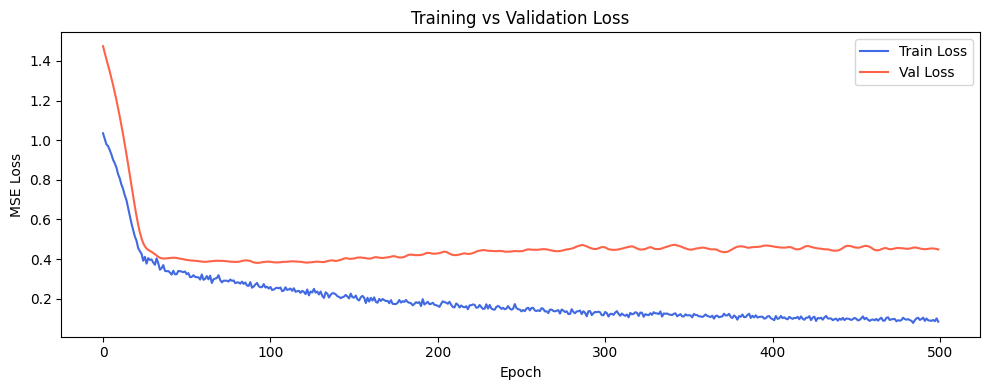

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss', color='royalblue')
plt.plot(val_losses,   label='Val Loss',   color='tomato')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Evaluation

In [10]:
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test_t).numpy().reshape(-1, 1)

# Inverse transform to original price scale
y_pred  = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_true  = scaler_y.inverse_transform(y_test).flatten()

r2   = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)

print('=' * 40)
print(f'  R² Score : {r2:.4f}')
print(f'  RMSE     : {rmse:,.0f}')
print(f'  MAE      : {mae:,.0f}')
print('=' * 40)

  R² Score : 0.6834
  RMSE     : 1,086,032
  MAE      : 799,221


## 7. Visualizations

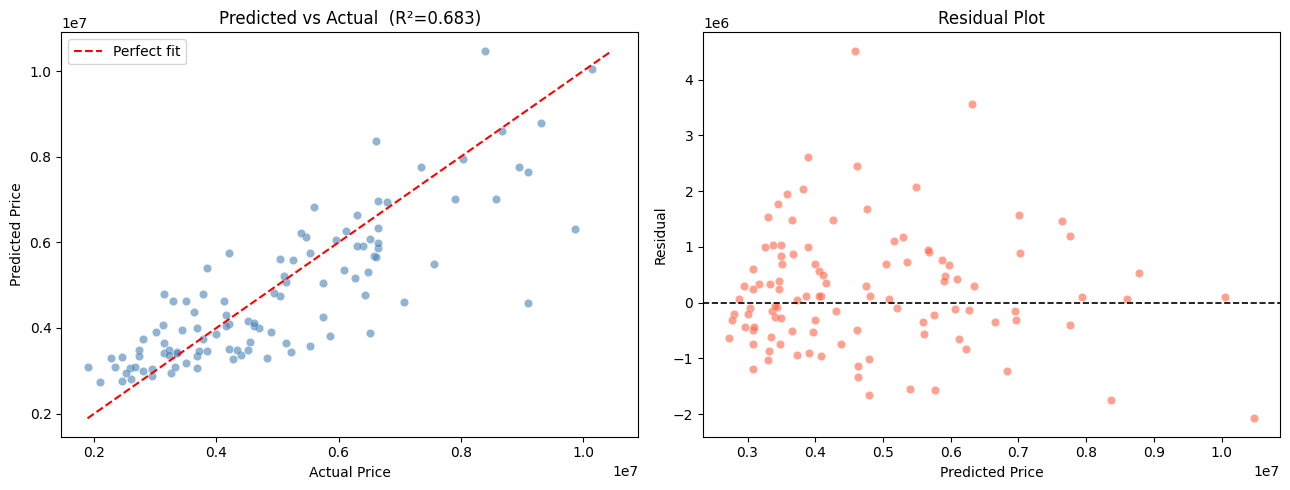

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicted vs Actual
axes[0].scatter(y_true, y_pred, alpha=0.6, color='steelblue', edgecolors='white', linewidth=0.3)
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title(f'Predicted vs Actual  (R²={r2:.3f})')
axes[0].legend()

# Residuals
residuals = y_true - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6, color='tomato', edgecolors='white', linewidth=0.3)
axes[1].axhline(0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

## 8. Save Model

In [12]:
torch.save({
    'model_state': model.state_dict(),
    'scaler_X': scaler_X,
    'scaler_y': scaler_y,
    'input_dim': input_dim,
}, 'housing_model.pth')
print('Model saved to housing_model.pth')

Model saved to housing_model.pth
